Original Shape: (7837, 24)

Null Values:

accident_id             0
city                    0
state                   0
latitude                0
longitude               0
date                    0
time                    0
hour                    0
day_of_week             0
is_weekend              0
road_type               0
lanes                   0
traffic_signal          0
weather                 0
visibility              0
temperature             0
traffic_density         0
cause                   0
accident_severity       0
vehicles_involved       0
casualties              0
is_peak_hour            0
festival             7797
risk_score              0
dtype: int64

Duplicate Rows: 0
Shape After Removing Duplicates: (7837, 24)

Remaining Columns:

['hour', 'day_of_week', 'is_weekend', 'road_type', 'lanes', 'traffic_signal', 'weather', 'visibility', 'temperature', 'traffic_density', 'cause', 'accident_severity', 'vehicles_involved', 'casualties', 'is_peak_hour', 'festival', 'risk_s

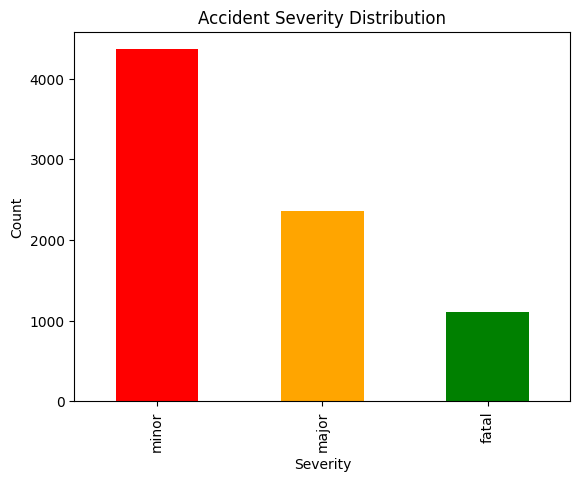

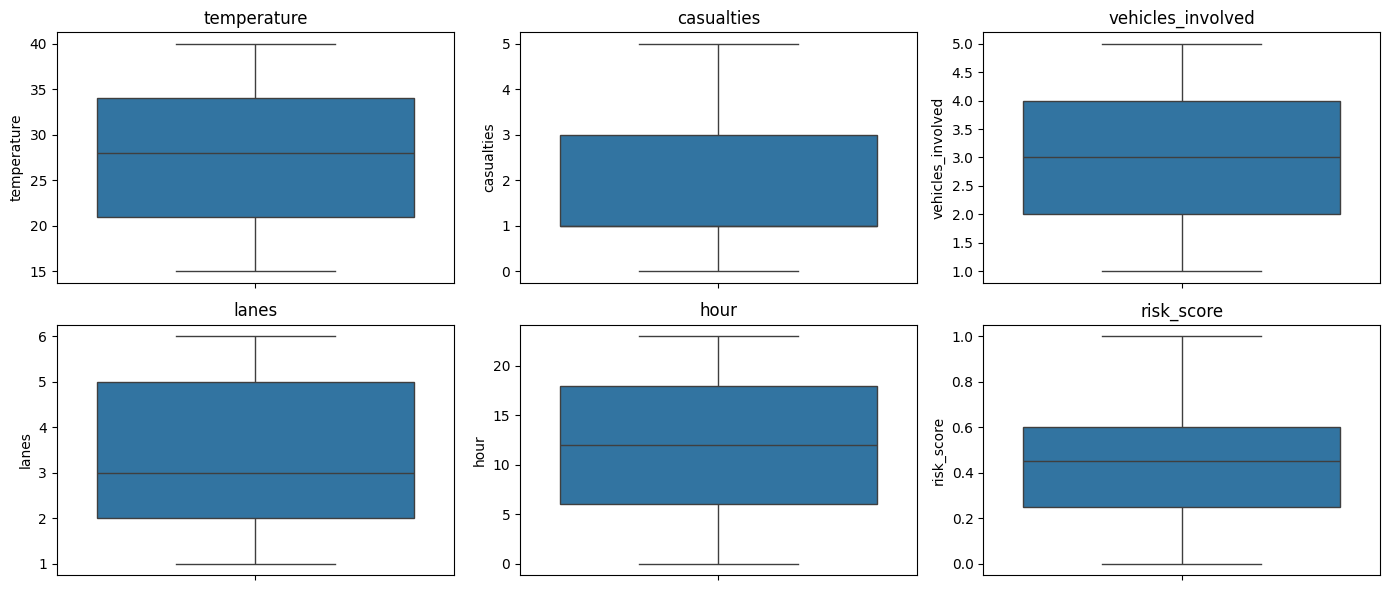


Target Classes:
['fatal' 'major' 'minor']

Feature Shape: (7837, 16)

Target Distribution:

accident_severity
2    4363
1    2362
0    1112
Name: count, dtype: int64

Before SMOTE:
{2: 4363, 1: 2362, 0: 1112}

After SMOTE:
{0: 4363, 1: 4363, 2: 4363}

Training Shape: (10471, 16)
Testing Shape: (2618, 16)

Preprocessing Completed Successfully!


In [1]:
# ==============================
# COMPLETE PREPROCESSING PIPELINE
# ==============================

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

# ------------------------------
# Load Dataset
# ------------------------------
df = pd.read_csv("indian_roads_dataset.csv")

print("Original Shape:", df.shape)

# ------------------------------
# Check Null Values
# ------------------------------
print("\nNull Values:\n")
print(df.isnull().sum())

# ------------------------------
# Remove Duplicates
# ------------------------------
print("\nDuplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape After Removing Duplicates:", df.shape)

# ------------------------------
# Drop Unnecessary Columns
# ------------------------------
drop_cols = [
    'accident_id',
    'date',
    'time',
    'latitude',
    'longitude',
    'city',
    'state'
]

df = df.drop(columns=drop_cols)

print("\nRemaining Columns:\n")
print(df.columns.tolist())

# ------------------------------
# Class Distribution
# ------------------------------
print("\nClass Distribution:\n")
print(df['accident_severity'].value_counts())

df['accident_severity'].value_counts().plot(
    kind='bar',
    color=['red', 'orange', 'green']
)

plt.title("Accident Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.show()

# ------------------------------
# Outlier Visualization
# ------------------------------
numerical_cols = [
    'temperature',
    'casualties',
    'vehicles_involved',
    'lanes',
    'hour',
    'risk_score'
]

plt.figure(figsize=(14, 6))

for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# ------------------------------
# Encode Categorical Columns
# ------------------------------
categorical_cols = [
    'day_of_week',
    'road_type',
    'weather',
    'visibility',
    'traffic_density',
    'cause',
    'festival'
]

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Encode Target Column
le_target = LabelEncoder()

df['accident_severity'] = le_target.fit_transform(
    df['accident_severity']
)

print("\nTarget Classes:")
print(le_target.classes_)

# ------------------------------
# Features and Target
# ------------------------------
X = df.drop(columns=['accident_severity'])
y = df['accident_severity']

print("\nFeature Shape:", X.shape)
print("\nTarget Distribution:\n")
print(y.value_counts())

# ------------------------------
# Handle Class Imbalance using SMOTE
# ------------------------------
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nBefore SMOTE:")
print(y.value_counts().to_dict())

print("\nAfter SMOTE:")
print(pd.Series(y_resampled).value_counts().to_dict())

# ------------------------------
# Train Test Split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# ------------------------------
# Feature Scaling
# ------------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nPreprocessing Completed Successfully!")

Random Forest Accuracy: 0.7815126050420168

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       908
           1       0.69      0.62      0.65       840
           2       0.68      0.73      0.70       870

    accuracy                           0.78      2618
   macro avg       0.78      0.78      0.78      2618
weighted avg       0.78      0.78      0.78      2618



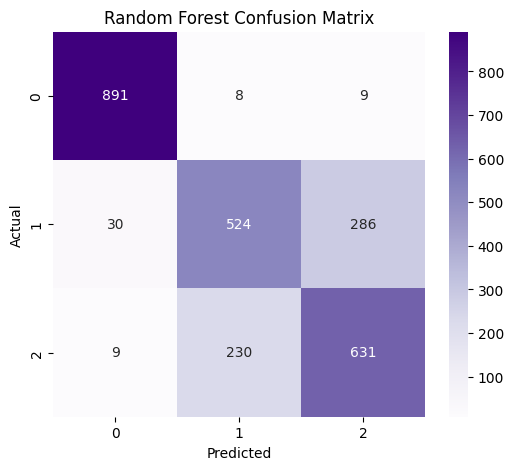

In [2]:
# =========================
# RANDOM FOREST CLASSIFIER
# =========================

# Imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# Create Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train Model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()